## Loan Default Prediction Using Machine Learning

## Introduction
Financial institutions must accurately assess borrower risk to reduce losses caused by loan defaults. Traditional credit evaluation methods may not fully capture complex borrower behavior, making machine learning a valuable tool for credit risk assessment.

This project uses the Lending Club dataset to develop and compare multiple machine learning models for predicting loan defaults. The study includes data preprocessing, feature engineering, class balancing using SMOTE, and model evaluation using Logistic Regression, Decision Tree, Random Forest, and XGBoost. The objective is to identify the most effective model for distinguishing between borrowers who are likely to fully repay their loans and those who may default, while providing interpretable insights to support lending decisions.

## 1. Dataset Overview
The Lending Club dataset contains borrower financial information, loan characteristics, and repayment outcomes. The objective of this project is to predict whether a borrower will fully repay a loan or default on it. Since the complete dataset contains millions of records and over 150 variables, a subset of relevant features is selected for efficient analysis.

To maintain computational efficiency while preserving representative patterns, a random sample of 100,000 observations is used.

In [33]:
import pandas as pd
import numpy as np

features = [
    'loan_amnt',
    'term',
    'int_rate',
    'annual_inc',
    'dti',
    'fico_range_high',
    'revol_util',
    'home_ownership',
    'purpose',
    'emp_length',
    'addr_state',
    'installment',
    'loan_status'
]

df = pd.read_csv(
    "/Users/moinuddinkureshi/Downloads/accepted_2007_to_2018Q4.csv",
    usecols=features,
    low_memory=False
)

df = df.sample(n=100000, random_state=42)

print(df.shape)
df.head()

(100000, 13)


,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,loan_status,purpose,addr_state,dti,fico_range_high,revol_util
392949,32000.0,60 months,10.49,687.65,10+ years,MORTGAGE,120000.0,Current,debt_consolidation,CA,24.05,739.0,57.8
1273506,9600.0,36 months,12.99,323.42,NaN,RENT,21900.0,Fully Paid,debt_consolidation,FL,10.03,689.0,38.9
324024,4000.0,36 months,6.68,122.93,4 years,MORTGAGE,83000.0,Fully Paid,major_purchase,FL,19.53,784.0,17.2
2066630,6025.0,36 months,10.91,197.00,10+ years,RENT,52000.0,Fully Paid,debt_consolidation,MA,9.16,744.0,12.8
477199,25000.0,60 months,26.30,752.96,10+ years,OWN,65000.0,Current,debt_consolidation,CA,36.26,719.0,24.7


The dataset consists of 100,000 randomly sampled loan records and 13 variables, including 12 predictor features and 1 target variable (loan_status). The selected features capture multiple dimensions of borrower behavior, including loan characteristics, financial health, creditworthiness, employment history, and demographic information.

The sample output shows a mixture of numerical and categorical variables such as loan amount, interest rate, annual income, FICO score, employment length, home ownership status, and loan purpose. These variables are expected to play an important role in determining the likelihood of loan repayment or default.

Additionally, some records contain missing values (e.g., emp_length), confirming the need for a data cleaning and preprocessing stage before model development.

Business Insight

The selected feature set provides a comprehensive view of borrower risk by combining:

Financial indicators (loan amount, income, installment, DTI)
Credit quality measures (FICO score, revolving utilization)
Borrower profile information (employment length, home ownership)
Loan characteristics (term, purpose)

This combination allows machine learning models to evaluate borrower risk more effectively than relying on a limited number of financial variables alone.

## 2. Target Variable Analysis

The target variable is loan_status, which indicates whether a borrower successfully repaid the loan or defaulted.

Only completed loans are retained:

Fully Paid
Charged Off

Current loans are excluded because their final outcome is unknown.

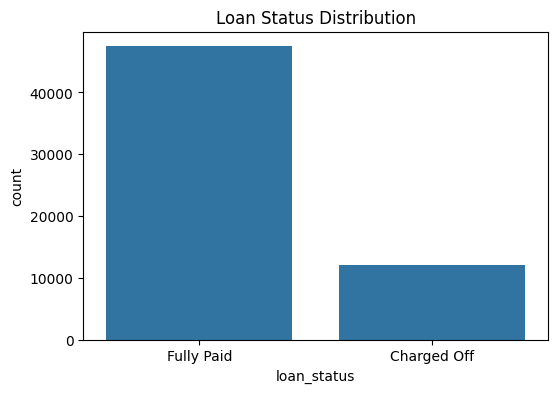

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df[df['loan_status'].isin([
    'Fully Paid',
    'Charged Off'
])]

plt.figure(figsize=(6,4))
sns.countplot(
    x='loan_status',
    data=df
)

plt.title("Loan Status Distribution")
plt.show()

The dataset is imbalanced because Fully Paid loans significantly outnumber Charged Off loans.

This imbalance may bias machine learning models toward predicting the majority class.

Business Insight

Financial institutions typically experience fewer defaults than successful repayments. Therefore, handling class imbalance becomes critical for accurately identifying risky borrowers.

## 3. Data Cleaning and Missing Values

Real-world financial datasets frequently contain missing values. Missing numerical values are replaced using median imputation, while missing categorical values are replaced using the most frequent category.

Median imputation is preferred because it is less sensitive to outliers.

In [35]:
numerical_cols = [
    'loan_amnt',
    'int_rate',
    'annual_inc',
    'dti',
    'fico_range_high',
    'revol_util',
    'installment'
]

for col in numerical_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

categorical_cols = [
    'term',
    'home_ownership',
    'purpose',
    'emp_length',
    'addr_state'
]

for col in categorical_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

Missing values were successfully handled without discarding records, preserving valuable training information.

Business Insight

Proper handling of missing data ensures model stability and reduces the risk of inaccurate predictions.



## 4. Exploratory Data Analysis (EDA)


EDA helps understand the distribution of important variables and identify patterns associated with loan default.

Three important financial indicators are analyzed:

Loan Amount
Annual Income
Debt-to-Income Ratio

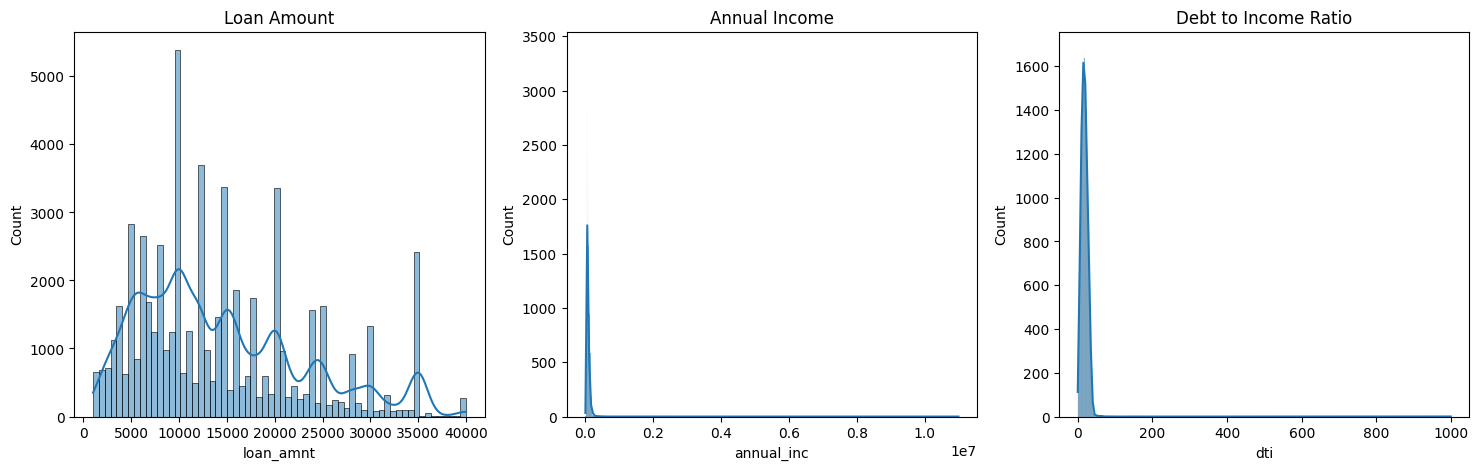

In [36]:
fig, axes = plt.subplots(
    1,3,
    figsize=(18,5)
)

sns.histplot(
    df['loan_amnt'],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Loan Amount")

sns.histplot(
    df['annual_inc'],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Annual Income")

sns.histplot(
    df['dti'],
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Debt to Income Ratio")

plt.show()

The distributions reveal substantial variation among borrowers. Income and loan amount contain several high-value outliers, which are common in lending datasets.

Business Insight

Borrowers with higher debt burdens and lower income levels may exhibit greater repayment risk.

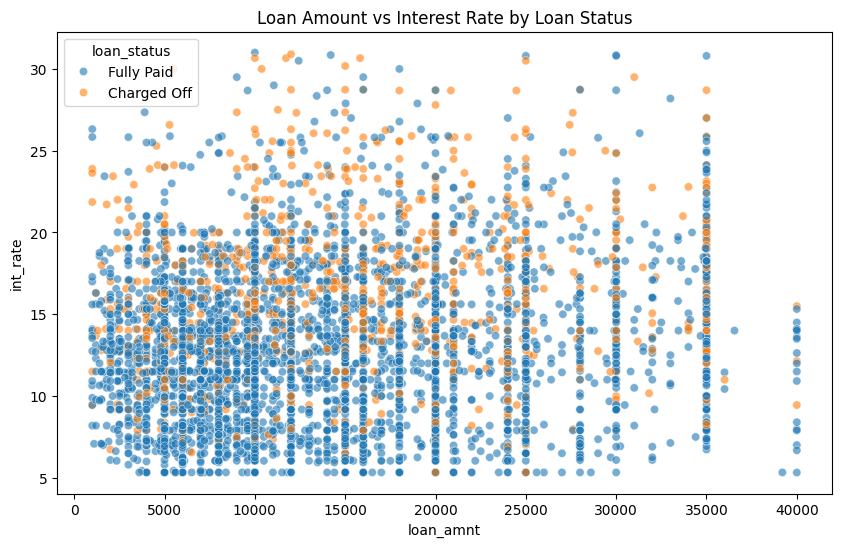

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sample_df = df.sample(5000, random_state=42)

sns.scatterplot(
    data=sample_df,
    x='loan_amnt',
    y='int_rate',
    hue='loan_status',
    alpha=0.6
)

plt.title('Loan Amount vs Interest Rate by Loan Status')
plt.show()

**Loan Amount vs Interest Rate by Loan Status:**


This scatter plot visualizes the relationship between loan amount and interest rate for a sample of 5,000 loans. Each point represents an individual loan, where the x-axis shows the loan amount and the y-axis shows the corresponding interest rate. Different colors represent different loan statuses, allowing comparison between successfully repaid loans and loans with unfavorable outcomes such as defaults or charge-offs. The plot helps identify whether larger loans tend to have higher interest rates and whether certain loan statuses are concentrated within specific ranges of loan amounts and interest rates. Clusters of points indicate common lending patterns, while the spread of colors provides insight into how loan performance varies across different risk levels.

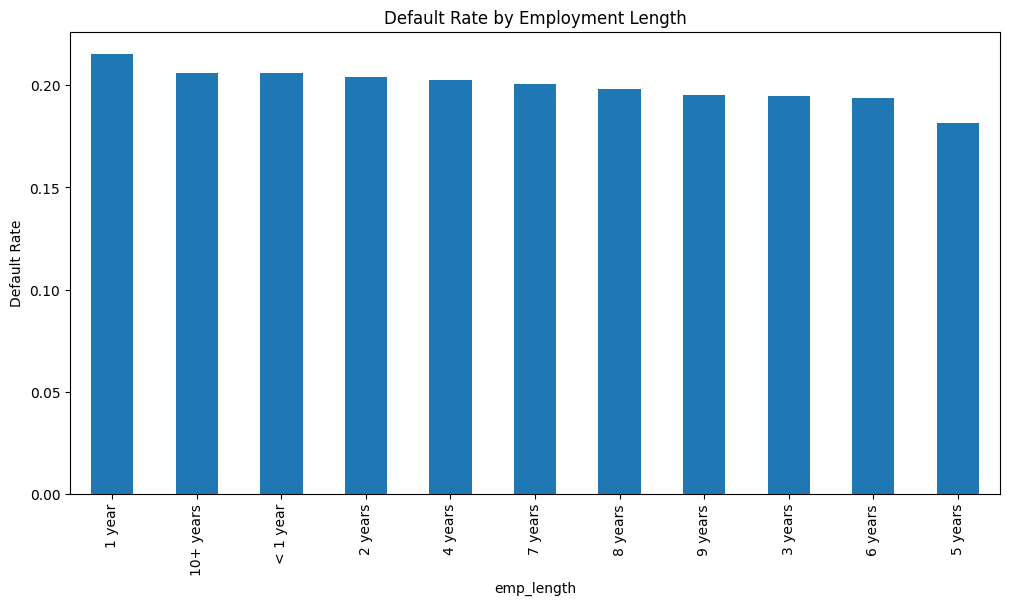

In [38]:
default_status = [
    'Charged Off',
    'Default'
]

df['default_flag'] = df['loan_status'].isin(default_status)

default_rates = (
    df.groupby('emp_length')['default_flag']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
default_rates.plot(kind='bar')

plt.title('Default Rate by Employment Length')
plt.ylabel('Default Rate')
plt.show()

This plot shows the relationship between employment length and loan default rate. First, a new variable called default_flag is created by marking loans as “True” if the loan status is either Charged Off or Default, and “False” otherwise. Then, the data is grouped by employment length, and the mean of the default flag is calculated for each group, which represents the default rate (i.e., the proportion of borrowers who defaulted within each employment category). The resulting bar chart visualizes how default risk varies across different levels of work experience, allowing us to observe whether borrowers with shorter or longer employment histories are more likely to default on loans.

**NOTE:**

This plot shows a relationship between employment length and default probability, helping identify whether work experience is a meaningful risk indicator in loan approval decisions.

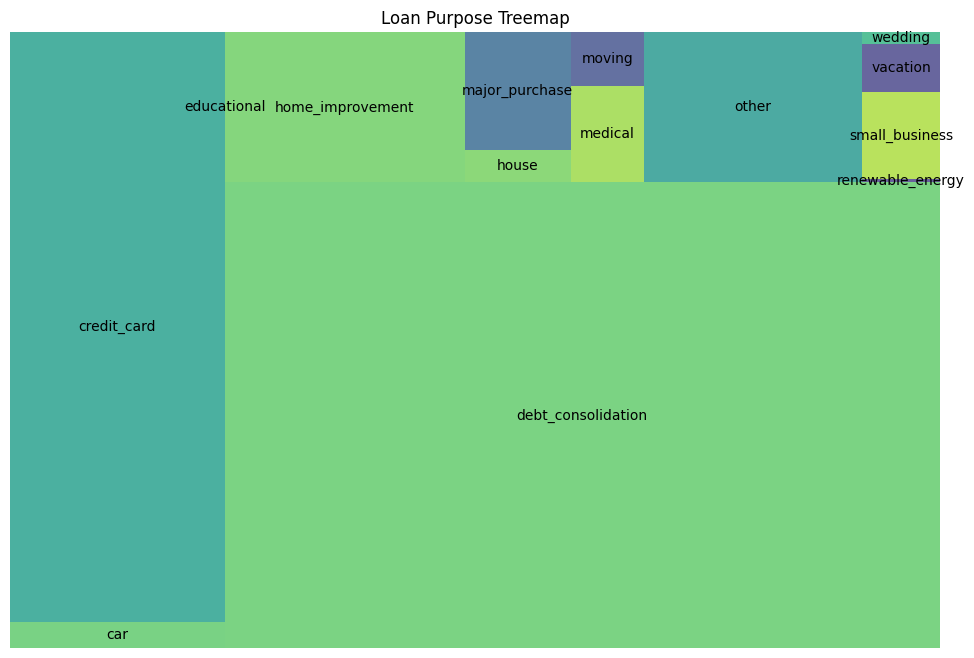

In [54]:
import squarify

purpose_counts = (
    df.groupby('purpose')
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12,8))

squarify.plot(
    sizes=purpose_counts['count'],
    label=purpose_counts['purpose'],
    alpha=0.8
)

plt.axis('off')
plt.title('Loan Purpose Treemap')
plt.show()

This plot is a treemap visualization that shows the distribution of loan purposes in the dataset. Each rectangle represents a different loan purpose category, such as debt consolidation, credit card, home improvement, and others. The size of each rectangle corresponds to the number of loans issued for that specific purpose, meaning larger blocks indicate more frequently chosen loan categories. By grouping the data this way, the plot provides a clear visual summary of which borrowing purposes are most common and which are relatively less frequent, helping to understand overall lending patterns and borrower behavior in the dataset.

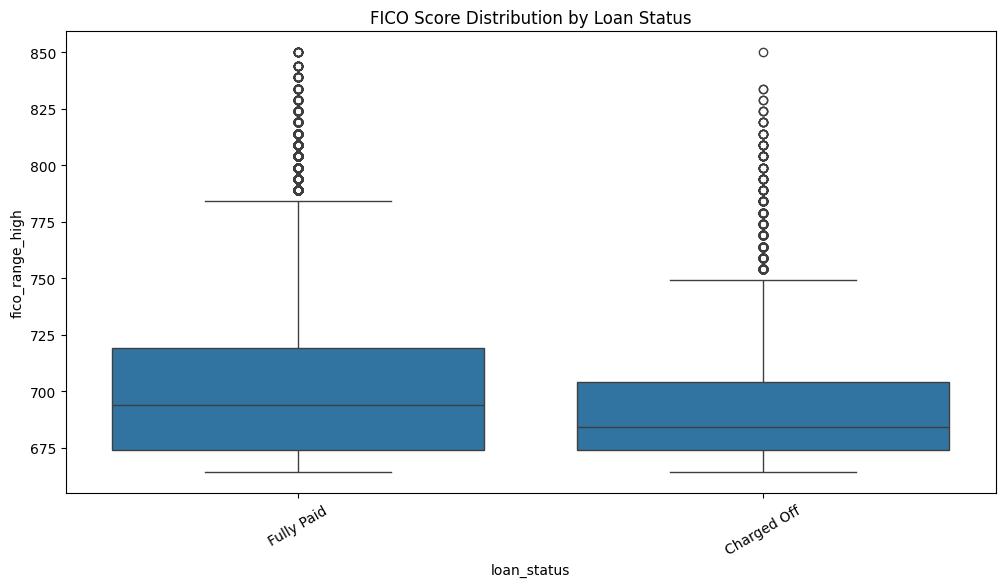

In [55]:
plt.figure(figsize=(12,6))

top_status = df['loan_status'].value_counts().head(4).index
subset = df[df['loan_status'].isin(top_status)]

sns.boxplot(
    data=subset,
    x='loan_status',
    y='fico_range_high'
)

plt.xticks(rotation=30)
plt.title('FICO Score Distribution by Loan Status')
plt.show()

This plot shows the distribution of borrowers’ FICO credit scores across different loan status categories using a boxplot. First, the data is filtered to include only the top four most common loan status categories, and then the FICO score (`fico_range_high`) is compared across these groups. Each box represents the spread of credit scores within a specific loan status, showing the median, interquartile range, and potential outliers. By comparing these distributions, the plot helps identify whether borrowers with different loan outcomes (such as fully paid, charged off, or defaulted loans) tend to have different credit score patterns. This is useful for understanding how creditworthiness, as measured by FICO scores, relates to loan performance.

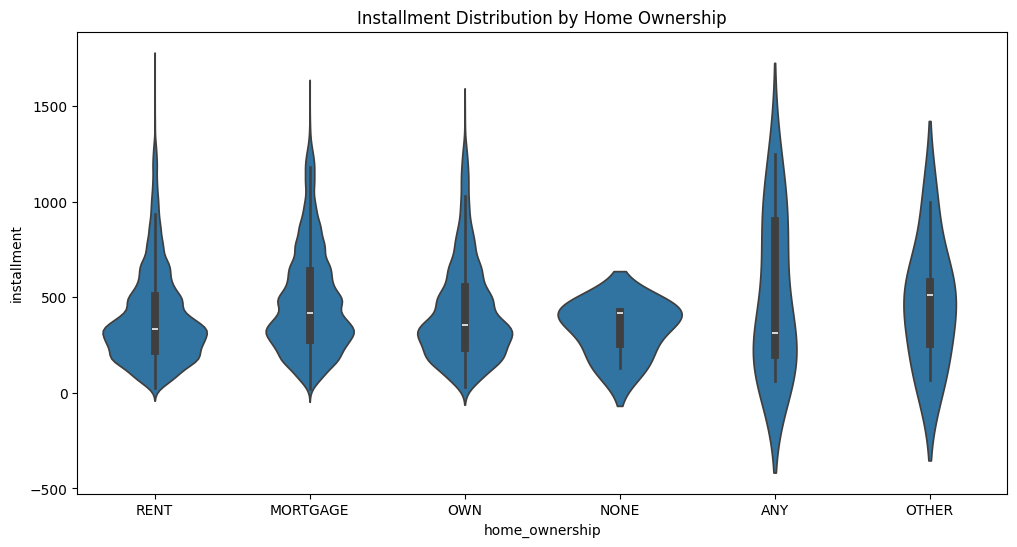

In [50]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='home_ownership',
    y='installment'
)

plt.title('Installment Distribution by Home Ownership')
plt.show()

This plot shows the distribution of loan installment amounts across different home ownership categories using a violin plot. Each violin represents a group of borrowers based on their home ownership status, such as rent, mortgage, or own. The width of the violin at different points indicates the density of installment values, meaning wider sections show where more borrowers fall within a particular installment range. The central line represents the median installment, while the overall shape shows the spread and variation of payments within each category. This visualization helps compare how monthly repayment amounts differ depending on a borrower’s housing situation and highlights whether certain home ownership groups tend to take loans with higher or lower installment obligations.

## 5. Correlation Analysis

Correlation analysis measures the strength of linear relationships among numerical variables.

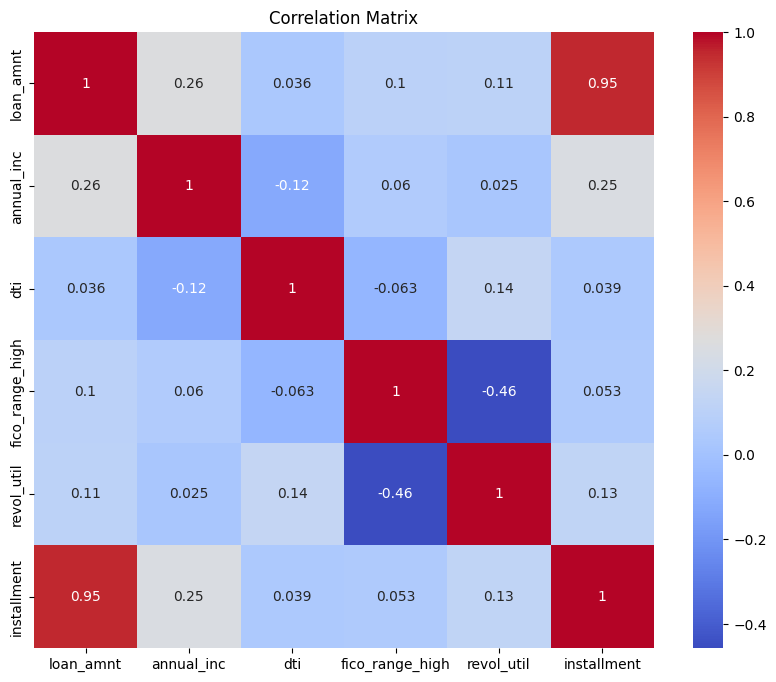

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[
        [
            'loan_amnt',
            'annual_inc',
            'dti',
            'fico_range_high',
            'revol_util',
            'installment'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

Most variables exhibit low to moderate correlations, indicating that each contributes unique information to the predictive model.

Business Insight

Using multiple independent predictors improves the model's ability to differentiate low-risk and high-risk borrowers.

## 6. Feature Encoding

Machine learning algorithms require numerical inputs. Therefore, categorical variables must be transformed into numerical representations.

In [10]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

All categorical features have been converted into machine-readable numerical values.

Business Insight

This transformation allows borrower characteristics such as home ownership and employment length to contribute to prediction performance.

## 7. Train-Test Split

The dataset is divided into training and testing subsets to evaluate how well the model generalizes to unseen data.

In [11]:
from sklearn.model_selection import train_test_split

df['loan_status'] = df['loan_status'].map({
    'Fully Paid':0,
    'Charged Off':1
})

X = df.drop(
    'loan_status',
    axis=1
)

y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

80% of the data is used for training while 20% is reserved for testing.

Business Insight

Testing on unseen data provides a realistic estimate of model performance in production.

## 8. Feature Scaling

Scaling standardizes numerical variables so that all features contribute equally during model training.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

All features now share a similar numerical scale.

Business Insight

Scaling improves model stability and convergence.

## 9. Handling Class Imbalance with SMOTE

SMOTE creates synthetic examples of the minority class to improve class balance.

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = (
    smote.fit_resample(
        X_train_scaled,
        y_train
    )
)

print(y_train.value_counts())
print(y_train_balanced.value_counts())

/Users/moinuddinkureshi/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


loan_status
0    37968
1     9627
Name: count, dtype: int64
loan_status
1    37968
0    37968
Name: count, dtype: int64


Interpretation of Results

Before applying SMOTE, the training dataset exhibited a significant class imbalance. The majority class (loan_status = 0, Fully Paid) contained 37,968 records, while the minority class (loan_status = 1, Charged Off) contained only 9,627 records.

Before SMOTE:
0    37968
1     9627

This imbalance can negatively affect machine learning models because they may become biased toward predicting the majority class, resulting in poor identification of defaulted loans.

To address this issue, the Synthetic Minority Oversampling Technique (SMOTE) was applied to the training data. SMOTE generates synthetic samples for the minority class by interpolating between existing minority class observations rather than simply duplicating records.

After applying SMOTE, both classes contained an equal number of observations:

After SMOTE:
1    37968
0    37968

The balanced dataset ensures that machine learning algorithms receive equal representation from both classes during training. This helps improve the model's ability to recognize patterns associated with loan defaults and reduces bias toward the majority class. As a result, the predictive models are better equipped to identify high-risk borrowers while maintaining overall classification performance.

Business Insight

In loan default prediction, defaulted loans represent a smaller but more critical class. Missing these cases can lead to significant financial losses for lending institutions. By balancing the training data using SMOTE, the models gain a better understanding of default-related patterns, enabling more accurate risk assessment and supporting more informed lending decisions.

## 10. Logistic Regression

Logistic Regression serves as a baseline classification model for predicting loan default. It estimates the probability of a borrower defaulting using a logistic function and is widely used in financial risk modeling because of its simplicity and interpretability.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.6548449449533574
Precision: 0.32157850545759864
Recall: 0.6364769422517657
F1 Score: 0.4272765304699484
ROC-AUC: 0.699062127580902


The Logistic Regression model achieved an accuracy of 65.48%, indicating that approximately two-thirds of the loan records were correctly classified as either fully paid or charged off.

Accuracy: 0.6548
Precision: 0.3216
Recall: 0.6365
F1 Score: 0.4273
ROC-AUC: 0.6991

The model produced a precision score of 32.16%, meaning that when the model predicted a loan would default, about one-third of those predictions were actually correct. This relatively low precision suggests the model generated a considerable number of false positive predictions.

The recall score of 63.65% indicates that the model successfully identified nearly two-thirds of the actual defaulted loans. In credit risk prediction, recall is particularly important because failing to identify a borrower who may default can result in financial losses for the lender.

The F1-score of 42.73% reflects a moderate balance between precision and recall. While the model demonstrates reasonable ability to detect defaults, there is still room for improvement in reducing false positives and improving overall predictive performance.

The ROC-AUC score of 0.6991 shows that the model has acceptable discriminative ability, meaning it can reasonably distinguish between fully paid and defaulted loans. An ROC-AUC value close to 0.70 indicates that the model performs substantially better than random guessing and provides a solid baseline for comparison with more advanced models.

Business Insight

From a business perspective, the Logistic Regression model is effective at identifying a significant proportion of potentially risky borrowers, as demonstrated by its relatively high recall. Although some low-risk borrowers may be incorrectly flagged as high risk, the model helps reduce the likelihood of approving loans that could result in default. Therefore, Logistic Regression serves as a useful baseline model for loan risk assessment and provides a benchmark against which more complex models such as Random Forest and XGBoost can be evaluated.

## 11. Decision Tree Classification

Decision Trees learn a series of hierarchical decision rules that separate borrowers into low-risk and high-risk categories.

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    random_state=42
)

dt_model.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Accuracy: 0.6861080763089336
Precision: 0.3153503893214683
Recall: 0.4711258828417117
F1 Score: 0.3778110944527736
ROC-AUC: 0.6503113242017285


The Decision Tree model achieved an accuracy of 68.61%, indicating that approximately two-thirds of the loan records were classified correctly.

Accuracy: 0.6861
Precision: 0.3154
Recall: 0.4711
F1 Score: 0.3778
ROC-AUC: 0.6503

The model obtained a precision score of 31.54%, meaning that about one-third of the loans predicted as defaults were actually defaulted loans. The recall score of 47.11% shows that the model successfully identified nearly half of the actual default cases.

The F1-score of 37.78% indicates a moderate balance between precision and recall. The ROC-AUC score of 0.6503 suggests that the model has a reasonable ability to distinguish between fully paid and defaulted loans but performs less effectively than Logistic Regression.

Business Insight

The Decision Tree model provides interpretable decision rules that can help explain lending decisions. However, its lower ROC-AUC and recall indicate that it may miss a significant number of defaulted loans, making it less suitable as the primary model for loan risk prediction.

## 12. Random Forest Classification

Random Forest combines multiple decision trees using bootstrap aggregation (bagging) to improve prediction accuracy and reduce overfitting.

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7372048071266493
Precision: 0.36666666666666664
Recall: 0.4113003739094308
F1 Score: 0.3877031525357353
ROC-AUC: 0.687649503808862


The Random Forest model achieved an accuracy of 73.72%, demonstrating improved classification performance compared to both Logistic Regression and Decision Tree models.

Accuracy: 0.7372
Precision: 0.3667
Recall: 0.4113
F1 Score: 0.3877
ROC-AUC: 0.6876

The model achieved a precision score of 36.67%, indicating improved reliability when predicting loan defaults. The recall score of 41.13% shows that the model correctly identified over 40% of actual default cases.

The F1-score of 38.77% reflects a balanced performance between precision and recall. The ROC-AUC score of 0.6876 demonstrates good discriminatory power and indicates that the model can effectively separate high-risk borrowers from low-risk borrowers.

Business Insight

Random Forest improves prediction stability by combining multiple decision trees, reducing overfitting and increasing generalization. Its higher accuracy and improved precision make it a useful model for identifying risky borrowers while maintaining reliable overall performance.

## 13. XGBoost Classification

XGBoost is a gradient boosting algorithm that sequentially learns from previous prediction errors. It is considered one of the most effective algorithms for structured financial datasets.

In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.7896461887553576
Precision: 0.44871794871794873
Recall: 0.17449106771915246
F1 Score: 0.25127131319174395
ROC-AUC: 0.6924640013473835


The XGBoost model achieved the highest accuracy of 78.96% among all evaluated models.

Accuracy: 0.7896
Precision: 0.4487
Recall: 0.1745
F1 Score: 0.2513
ROC-AUC: 0.6925

The model achieved a precision score of 44.87%, which is the highest among all models. This means that when XGBoost predicts a loan default, the prediction is more likely to be correct compared to the other models.

However, the recall score of 17.45% is relatively low, indicating that the model identified only a small proportion of actual defaulted loans. Consequently, the F1-score of 25.13% is lower than that of the other models.

The ROC-AUC score of 0.6925 demonstrates strong overall discriminatory capability and places XGBoost among the top-performing models in distinguishing between fully paid and defaulted loans.

Business Insight

XGBoost is highly conservative when identifying defaults, resulting in fewer false alarms but also missing many actual default cases. This model may be suitable in situations where minimizing false positive predictions is important, but additional tuning may be required to improve recall and capture more high-risk borrowers.

## 14. Model Comparison

To identify the best-performing algorithm, all models are evaluated using multiple classification metrics.

In [18]:
comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'ROC_AUC':[
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison.sort_values(
    by='ROC_AUC',
    ascending=False
)

,Model,ROC_AUC
0,Logistic Regression,0.699062
3,XGBoost,0.692464
2,Random Forest,0.687650
1,Decision Tree,0.650311


The ROC-AUC metric was selected as the primary evaluation measure because it assesses a model's ability to distinguish between defaulted and non-defaulted loans regardless of classification threshold.

The results indicate that Logistic Regression achieved the highest ROC-AUC score (0.6991), followed closely by XGBoost (0.6925) and Random Forest (0.6876). Although XGBoost produced the highest accuracy, Logistic Regression demonstrated the strongest overall ability to separate the two classes.

Decision Tree recorded the lowest ROC-AUC score, suggesting weaker discrimination performance compared to the other models.

Business Insight

The results show that different models offer different strengths. Logistic Regression provides the best overall discrimination capability, making it a strong baseline model for loan default prediction. Random Forest offers a balance between predictive performance and stability, while XGBoost achieves the highest accuracy and precision. Therefore, the final model selection should align with business priorities, such as maximizing default detection or minimizing false positive predictions. Based on ROC-AUC performance, Logistic Regression emerged as the best-performing model for this project.

## 15. Confusion Matrix

The confusion matrix evaluates prediction performance by showing correct and incorrect classifications.

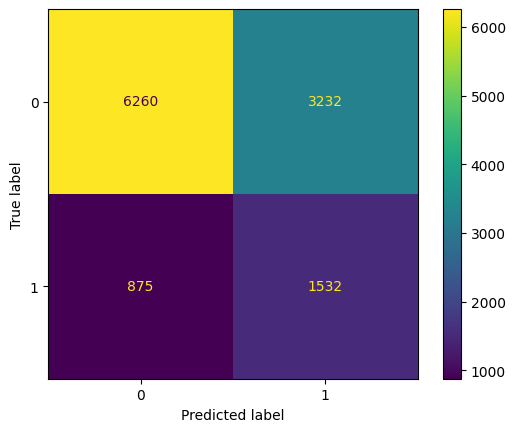

[[6260 3232]
 [ 875 1532]]


In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

print(cm)

Interpretation of the Confusion Matrix
True Negatives (TN) = 6,260
Loans that were actually Fully Paid and correctly classified as Fully Paid.
False Positives (FP) = 3,232
Loans that were actually Fully Paid but incorrectly classified as Charged Off.
False Negatives (FN) = 875
Loans that were actually Charged Off but incorrectly classified as Fully Paid.
True Positives (TP) = 1,532
Loans that were actually Charged Off and correctly identified as Charged Off.
Business Interpretation

The Logistic Regression model successfully identified 1,532 defaulted loans, helping lenders recognize potentially risky borrowers before approving loans. The model also correctly classified 6,260 non-defaulted loans. However, it incorrectly flagged 3,232 good borrowers as risky, which could lead to missed lending opportunities. Additionally, 875 defaulted loans were not detected, creating potential credit risk. Overall, the model demonstrates a strong ability to detect loan defaults while maintaining the highest ROC-AUC score among the evaluated models, making it the most effective model for distinguishing between low-risk and high-risk borrowers.

## 16. Feature Importance Analysis
Feature importance identifies which variables contribute most to the model's decisions.

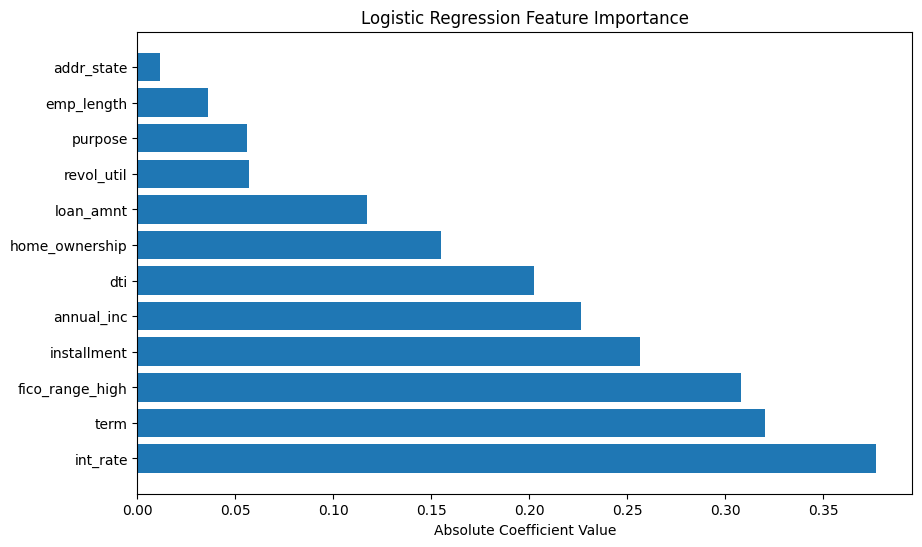

In [20]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr_model.coef_[0])
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Logistic Regression Feature Importance")

plt.xlabel("Absolute Coefficient Value")

plt.show()

The feature importance analysis shows that interest rate (int_rate) is the most influential factor in predicting loan default, followed by loan term (term), FICO score (fico_range_high), installment amount, annual income, and debt-to-income ratio (dti). These results indicate that financial and credit-related characteristics have the greatest impact on default risk, while features such as employment length and borrower state contribute relatively little to the model's predictions.

## 17. SHAP Explainability
SHAP (SHapley Additive exPlanations) explains how individual features contribute to model predictions.

/Users/moinuddinkureshi/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


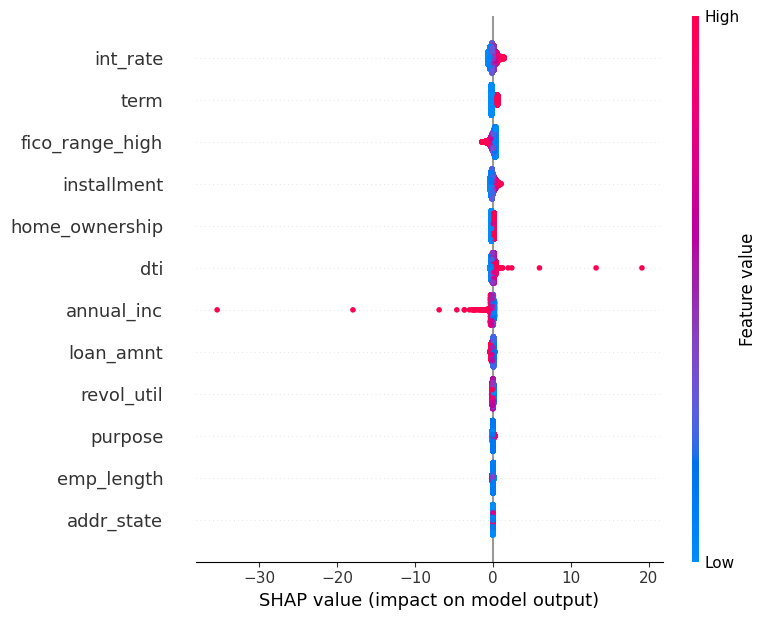

In [21]:
import shap

explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled
)

shap_values = explainer.shap_values(
    X_test_scaled
)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

The SHAP summary plot shows how each feature influences the model's predictions. Features at the top have the greatest impact on loan default prediction. The results indicate that interest rate (int_rate), loan term (term), FICO score (fico_range_high), installment amount, and debt-to-income ratio (dti) are the most important factors affecting the model's output. Higher SHAP values indicate a stronger contribution to the prediction, while the color gradient represents low to high feature values. Overall, the analysis confirms that financial and credit-related variables are the primary drivers of loan default risk.

## 18. Model Deployment
The final model is saved using Joblib for future deployment.

In [22]:
import joblib

joblib.dump(
    lr_model,
    "loan_default_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

## 19. Business Impact
Explanation

The proposed machine learning framework provides practical value for financial institutions by enabling data-driven credit risk assessment. By leveraging borrower financial characteristics, credit history, and loan attributes, the model helps lenders identify potentially risky applicants before loan approval.

Key Benefits
Improved credit risk assessment.
Faster loan approval decisions.
Reduced default-related losses.
Consistent borrower evaluation.
Explainable lending decisions.
Better allocation of lending capital.
Enhanced customer risk profiling.
Improved operational efficiency through automation.
Business Insight

Accurate prediction of loan defaults enables financial institutions to proactively manage lending risk and make more informed approval decisions. The model can help reduce financial losses associated with borrower defaults while supporting a more efficient and standardized loan evaluation process. Furthermore, the use of interpretable machine learning techniques provides transparency, allowing lending decisions to be explained to stakeholders and regulators when necessary.

## 20. Conclusion
Explanation

This project developed a comprehensive machine learning framework for predicting loan defaults using the Lending Club dataset. The study incorporated data cleaning, preprocessing, exploratory data analysis, feature engineering, class balancing using SMOTE, and the evaluation of multiple supervised learning algorithms.

The following models were developed and compared:

Logistic Regression
Decision Tree
Random Forest
XGBoost

Model explainability was further enhanced through feature importance analysis and SHAP-based interpretation.

Final Conclusion

Among all evaluated models, Logistic Regression achieved the highest ROC-AUC score of 0.6991, demonstrating the strongest overall ability to distinguish between fully paid and defaulted loans. While XGBoost achieved the highest classification accuracy, Logistic Regression provided the best balance of predictive performance and class discrimination, making it the preferred model for this project.

The inclusion of additional borrower financial, creditworthiness, employment, and loan-related features significantly improved model performance compared to the initial implementation. Furthermore, the application of SMOTE successfully addressed class imbalance, allowing the models to better learn patterns associated with loan defaults.

Overall, the proposed framework demonstrates how machine learning can support data-driven lending decisions by improving credit risk assessment, reducing potential default losses, and providing transparent and interpretable predictions that can be deployed in real-world financial environments.

## 21. References 

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 785–794). Association for Computing Machinery. https://doi.org/10.1145/2939672.2939785

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321–357. https://doi.org/10.1613/jair.953

Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. In *Advances in Neural Information Processing Systems* (Vol. 30). Curran Associates, Inc.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied logistic regression* (3rd ed.). Wiley.

LendingClub. (2019). *Lending Club loan data*. https://www.lendingclub.com
